In [9]:
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
from meteostat import Point, Hourly, Stations
from tqdm import tqdm

# 1) Pin a specific station (e.g., nearest to Copenhagen coords)
stations = Stations().nearby(55.6761, 12.5683).fetch(1)
station_id = stations.index[0]  # store this string somewhere permanent

# 2) Lock model + timezone; (optionally) extend cache age for stability
Hourly.max_age = 60 * 60 * 24 * 365  # keep cached files up to 1 year

def get_hourly_example(station_id, start, end):
    data = Hourly(station_id, start, end, timezone="Europe/Copenhagen", model=False)
    return data.fetch()

def plot_hourly_temperature(all_data: dict) -> None:
    fig, ax = plt.subplots(figsize=(17, 7))
    for city_name, df in all_data.items():
        if 'temp' in df.columns:
            df['temp'].plot(ax=ax, label=city_name)
        else:
            print(f"[{city_name}] 'temp' column missing – skipping.")
    ax.set_title("Hourly Temperature Comparison")
    ax.set_xlabel("Date")
    ax.set_ylabel("Temperature (°C)")
    ax.legend()
    plt.tight_layout()
    plt.show()

def run(start, end):
    all_data = {}
    for city in tqdm(["Copenhagen"], desc="Cities"):
        try:
            df = get_hourly_example(station_id, start, end)
            # sanity: ensure we really got 'temp' and the timezone we expect
            assert 'temp' in df.columns, "temp missing"
            assert str(df.index.tz) == "Europe/Copenhagen", df.index.tz
            all_data[city] = df
            tqdm.write(f"[{city}] ✅ {station_id} rows={len(df)}")
        except Exception as e:
            tqdm.write(f"[{city}] ❌ Error: {e}")
    if all_data:
        plot_hourly_temperature(all_data)

run(datetime(2025,1,1), datetime(2025,1,7))


Cities: 100%|██████████| 1/1 [00:00<00:00, 18.15it/s]

[Copenhagen] ❌ Error: None


In [10]:
from typing import Tuple, Dict, List, Union, Optional
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def static_world_map(
    bbox: Tuple[float, float, float, float],   # (lon_min, lon_max, lat_min, lat_max)
    points: Optional[Union[Dict[str, Tuple[float, float]], List[Tuple[float, float]]]] = None,
    borders_scale: str = "110m",
    figsize: Tuple[int, int] = (16, 10),
    show_labels: bool = True,
    land_color: Optional[str] = "#ece6d9",     # <-- add your colour here (hex or named)
    ocean_color: Optional[str] = None,         # e.g. "#a9cbe8"
):
    lon_min, lon_max, lat_min, lat_max = bbox

    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=proj)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

    # Base features (custom colours)
    if ocean_color:
        ax.add_feature(cfeature.OCEAN.with_scale(borders_scale), zorder=0, facecolor=ocean_color)
    else:
        ax.add_feature(cfeature.OCEAN.with_scale(borders_scale), zorder=0)

    if land_color:
        ax.add_feature(cfeature.LAND.with_scale(borders_scale), zorder=1, facecolor=land_color, edgecolor="none")
    else:
        ax.add_feature(cfeature.LAND.with_scale(borders_scale), zorder=1)

    ax.coastlines(resolution=borders_scale, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS.with_scale(borders_scale), linewidth=0.6)

    # Lakes & rivers
    lakes = cfeature.NaturalEarthFeature("physical", "lakes", borders_scale, edgecolor="none", facecolor="lightblue")
    ax.add_feature(lakes, zorder=2)
    rivers = cfeature.NaturalEarthFeature("physical", "rivers_lake_centerlines", borders_scale, edgecolor="lightblue", facecolor="none")
    ax.add_feature(rivers, linewidth=0.5, zorder=3)

    # Country outlines
    countries = cfeature.NaturalEarthFeature("cultural", "admin_0_countries", borders_scale, edgecolor="black", facecolor="none")
    ax.add_feature(countries, linewidth=0.3, zorder=3.5)

    # Points
    if points:
        items = points.items() if isinstance(points, dict) else [(f"P{i}", p) for i, p in enumerate(points, 1)]
        for name, (lat, lon) in items:
            ax.plot(lon, lat, "o", transform=proj, markersize=5, zorder=4)
            if show_labels:
                ax.text(lon, lat, f" {name}", transform=proj, fontsize=8, ha="left", va="bottom", zorder=4)

    gl = ax.gridlines(draw_labels=True, linewidth=0.2)
    gl.right_labels = False
    gl.top_labels = False

    plt.tight_layout()
    plt.show()


In [11]:
roman_cities = {
    "Roma (Rome)": (41.902, 12.496),
    "Ostia": (41.755, 12.288),
    "Neapolis (Naples)": (40.851, 14.268),
    "Capua": (41.105, 14.213),
    "Pompeii": (40.749, 14.486),

    "Mediolanum (Milan)": (45.464, 9.190),
    "Augusta Taurinorum (Turin)": (45.070, 7.686),
    "Augusta Praetoria (Aosta)": (45.737, 7.320),
    "Ticinum (Pavia)": (45.185, 9.160),
    "Placentia (Piacenza)": (45.052, 9.694),
    "Mutina (Modena)": (44.646, 10.925),
    "Bononia (Bologna)": (44.494, 11.343),
    "Ravenna": (44.418, 12.203),
    "Verona (Veronae)": (45.438, 10.992),
    "Brixia (Brescia)": (45.541, 10.211),
    "Patavium (Padua)": (45.407, 11.877),
    "Genua (Genoa)": (44.405, 8.946),

    "Aquileia": (45.768, 13.368),
    "Tergeste (Trieste)": (45.649, 13.776),
    "Emona (Ljubljana)": (46.056, 14.506),
    "Parentium (Poreč)": (45.227, 13.595),
    "Pola (Pula)": (44.869, 13.848),
    "Tarsatica (Rijeka)": (45.327, 14.442),
    "Senia (Senj)": (44.989, 14.905),

    "Iuvavum (Salzburg)": (47.809, 13.055),
    "Brigantium (Bregenz)": (47.503, 9.748),
    "Augusta Vindelicum (Augsburg)": (48.370, 10.898),
    "Castra Regina (Regensburg)": (49.019, 12.098),

    "Aventicum (Avenches)": (46.881, 7.047),
    "Augusta Raurica (near Basel)": (47.533, 7.716),
    "Vindonissa (Windisch)": (47.476, 8.216),
    "Turicum (Zurich)": (47.376, 8.541),
    "Genava (Geneva)": (46.204, 6.143),  # just inside your west edge
}


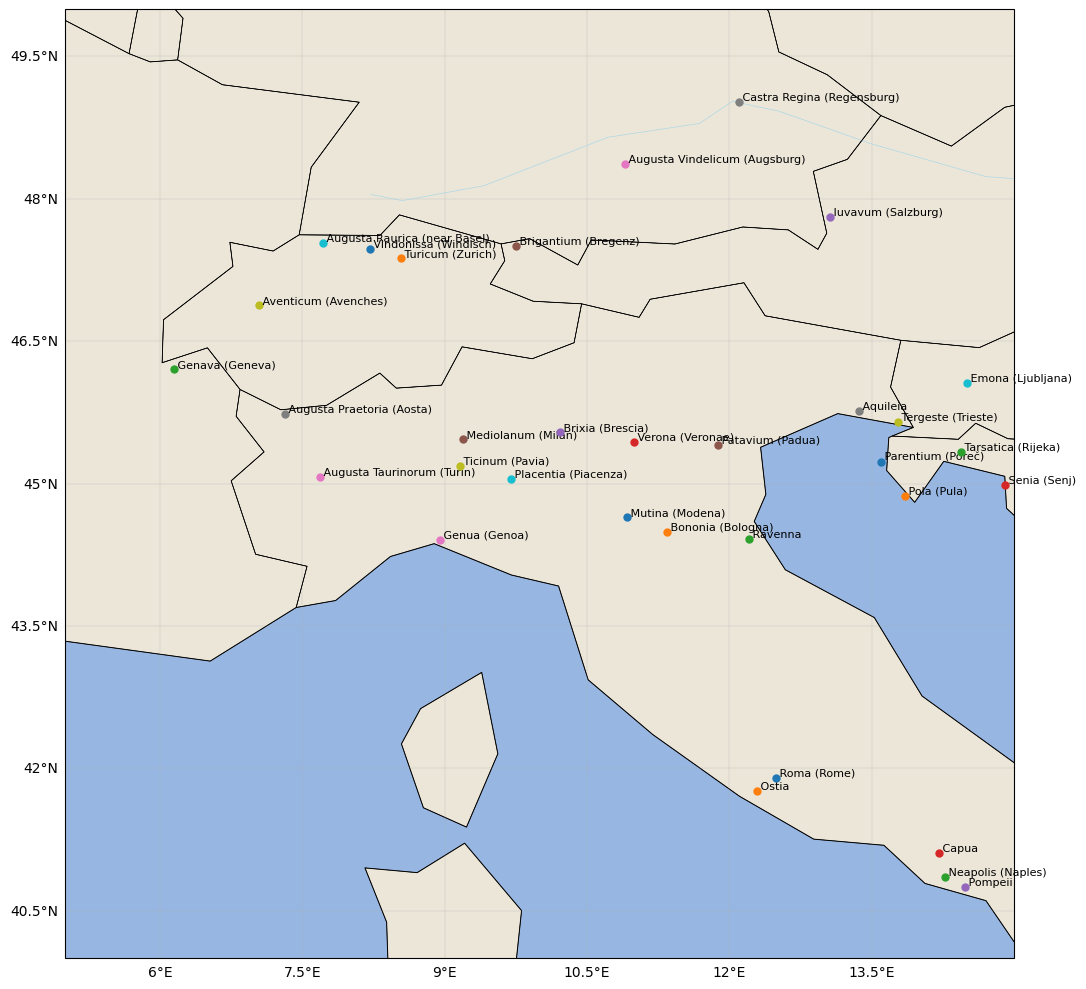

In [12]:
bbox = (5, 15, 40, 50)  # (lon_min, lon_max, lat_min, lat_max)
static_world_map(bbox, points=roman_cities, borders_scale="110m")

